# Análisis de Valores Atípicos (Outliers)
## Dataset: Medical Insurance Cost

**Fuente:** [Kaggle — Medical Cost Personal Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)  
**Descarga directa (sin cuenta Kaggle):**
```
https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv
```

**Tarea de minería de datos:** Predecir el costo de seguro médico de un individuo (`charges`) → **Regresión**

---

### Descripción del dataset

| Variable | Tipo | Descripción |
|---|---|---|
| `age` | Continua | Edad del beneficiario |
| `sex` | Binaria | Género (male / female) |
| `bmi` | Continua | Índice de Masa Corporal (IMC) |
| `children` | Discreta | Número de hijos cubiertos |
| `smoker` | Binaria | ¿Es fumador? (yes / no) |
| `region` | Nominal | Región de EE.UU. (NE / SE / SW / NW) |
| `charges` | Continua | Costos médicos facturados (USD) — **variable objetivo** |

### Objetivos del notebook
1. Detectar outliers mediante **métodos visuales**, el **método del RIC (Tukey)** y el **método de la Puntuación Z**
2. Distinguir entre **outliers genuinos** (casos reales) y **outliers espurios** (errores de datos)
3. Aplicar **conocimiento del dominio** para interpretar cada caso
4. **Justificar** la decisión de conservar o eliminar cada outlier
5. Cuantificar el **impacto** de los outliers en las estadísticas de resumen


---
## 0. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (11, 5)
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

print('✓ Librerías importadas correctamente.')

✓ Librerías importadas correctamente.


---
## 1. Carga del dataset

El dataset puede cargarse directamente desde GitHub sin necesidad de descargar ningún archivo:


In [2]:
# Opción A: cargar directamente desde GitHub (recomendado)
URL = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(URL)

# Opción B: si descargaste el archivo de Kaggle, descomenta la línea de abajo
# df = pd.read_csv('insurance.csv')

print(f'Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

Dataset cargado: 1338 filas × 7 columnas


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86


In [3]:
# Inspección inicial
print('Información general:')
df.info()
print(f'\nValores nulos: {df.isnull().sum().sum()}')
print(f'Duplicados:    {df.duplicated().sum()}')

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Valores nulos: 0
Duplicados:    1


---
## 2. Estadísticas descriptivas

Antes de buscar outliers, comprendemos la distribución general del dataset.


In [4]:
# Estadísticas de las variables numéricas
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


> **Primera señal de alerta:** En `charges`, la diferencia entre la mediana (`9,382`) y la media (`13,270`) es enorme.  
> Cuando la media >> mediana, hay **asimetría positiva** (cola derecha larga), lo que generalmente indica **outliers en los valores altos**.

> En `bmi`, el máximo es `53.13`, bastante por encima del rango clínicamente normal (18.5–24.9).


In [5]:
# Distribución de variables categóricas
for col in ['sex', 'smoker', 'region']:
    print(f'\n{col}:')
    print(df[col].value_counts())


sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


---
## 3. Análisis de Valores Atípicos (Outliers)

Un **outlier** es una observación que se aleja significativamente del comportamiento general de los datos.  
Existen dos tipos fundamentales:

| Tipo | Descripción | Acción típica |
|---|---|---|
| **Espurio** | Error de captura o de medición | Corregir o eliminar |
| **Genuino** | Caso real, inusual pero válido | Conservar y documentar |

Aplicaremos tres enfoques complementarios de detección:
1. **Visual** — histogramas, boxplots, violin plots
2. **Método del RIC (Tukey)** — basado en cuartiles
3. **Puntuación Z (Z-score)** — basado en desviaciones estándar


### 3.1 Detección visual

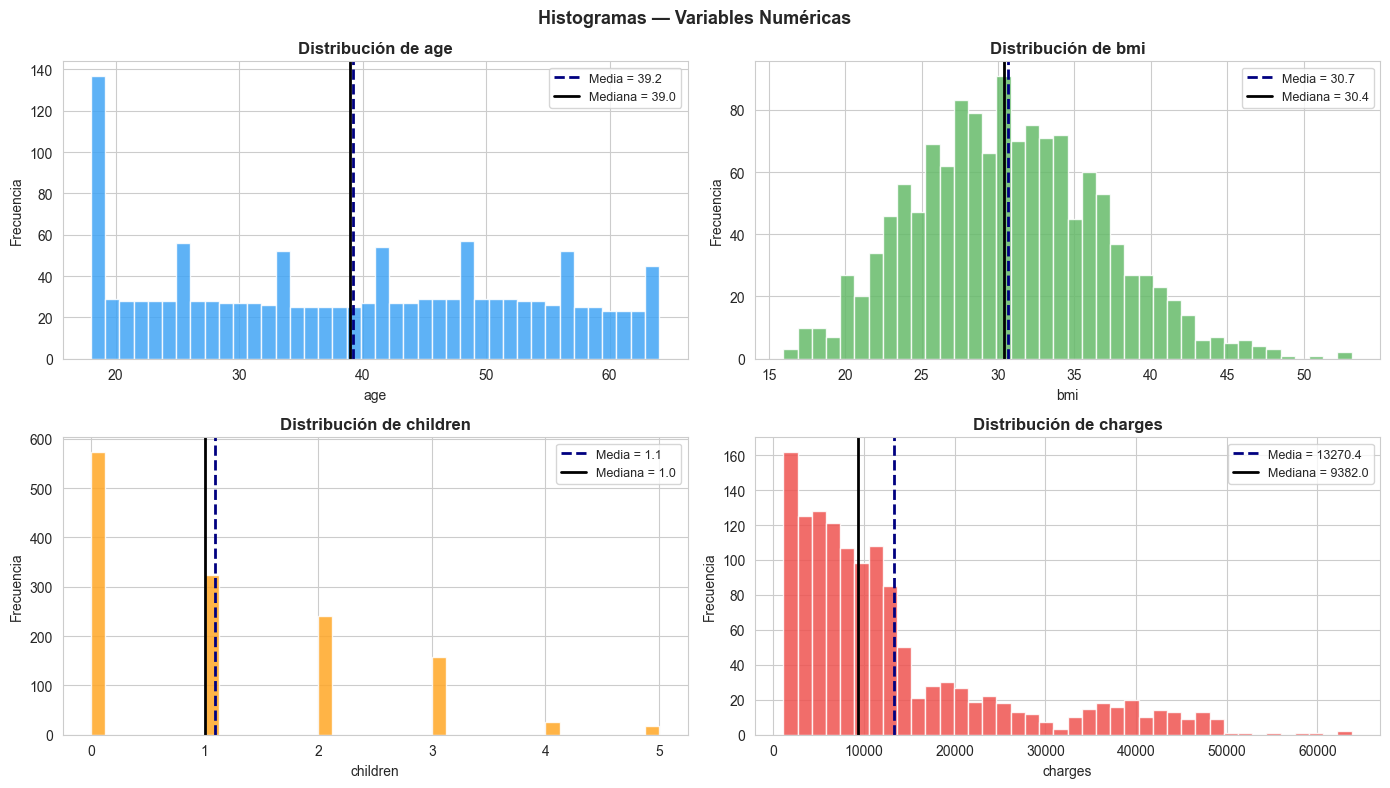

Observaciones:
  • age: distribución relativamente uniforme, sin outliers evidentes
  • bmi: distribución aproximadamente normal, algunos valores extremos altos
  • children: distribución discreta concentrada en 0-3
  • charges: distribución BIMODAL con cola derecha muy larga → SEÑAL DE ALERTA


In [6]:
# ── Histogramas de variables numéricas ──
vars_num = ['age', 'bmi', 'children', 'charges']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

colores = ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350']

for i, (var, color) in enumerate(zip(vars_num, colores)):
    ax = axes[i//2][i%2]
    ax.hist(df[var], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[var].mean(),   color='navy',   linewidth=2, linestyle='--', label=f'Media = {df[var].mean():.1f}')
    ax.axvline(df[var].median(), color='black',  linewidth=2, linestyle='-',  label=f'Mediana = {df[var].median():.1f}')
    ax.set_title(f'Distribución de {var}', fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Histogramas — Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observaciones:')
print('  • age: distribución relativamente uniforme, sin outliers evidentes')
print('  • bmi: distribución aproximadamente normal, algunos valores extremos altos')
print('  • children: distribución discreta concentrada en 0-3')
print('  • charges: distribución BIMODAL con cola derecha muy larga → SEÑAL DE ALERTA')

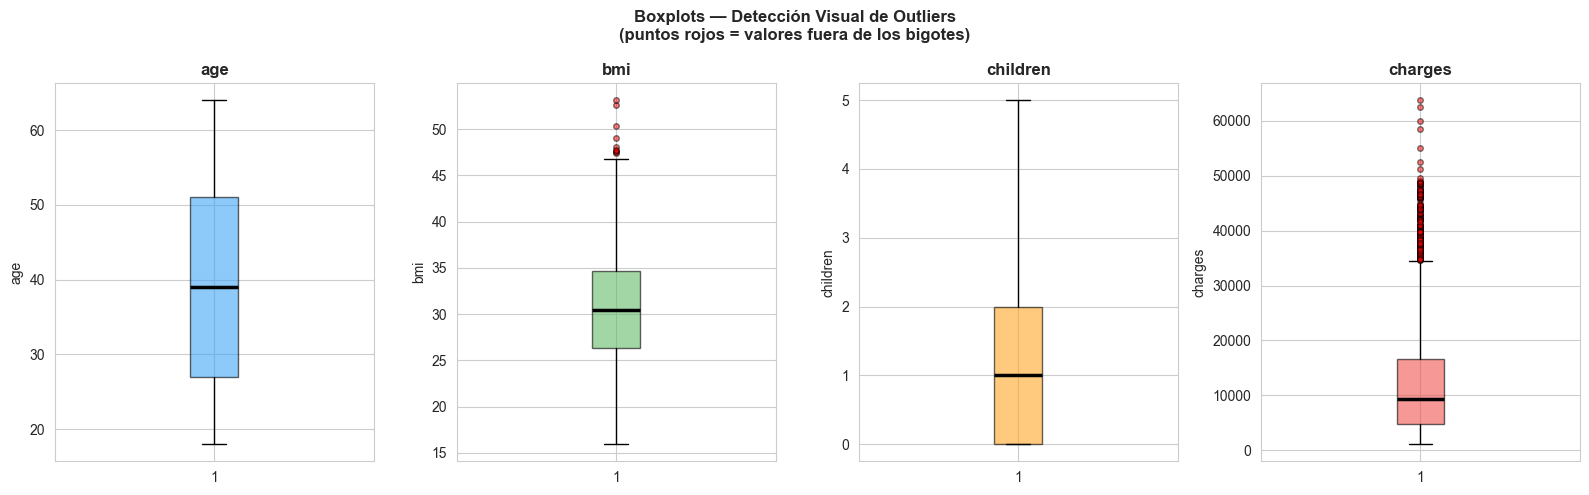

In [7]:
# ── Boxplots ──
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, (var, color) in enumerate(zip(vars_num, colores)):
    bp = axes[i].boxplot(df[var], patch_artist=True,
                         boxprops=dict(facecolor=color, alpha=0.6),
                         medianprops=dict(color='black', linewidth=2.5),
                         flierprops=dict(marker='o', markerfacecolor='red',
                                         markersize=4, alpha=0.5))
    axes[i].set_title(f'{var}', fontweight='bold')
    axes[i].set_ylabel(var)

plt.suptitle('Boxplots — Detección Visual de Outliers\n(puntos rojos = valores fuera de los bigotes)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

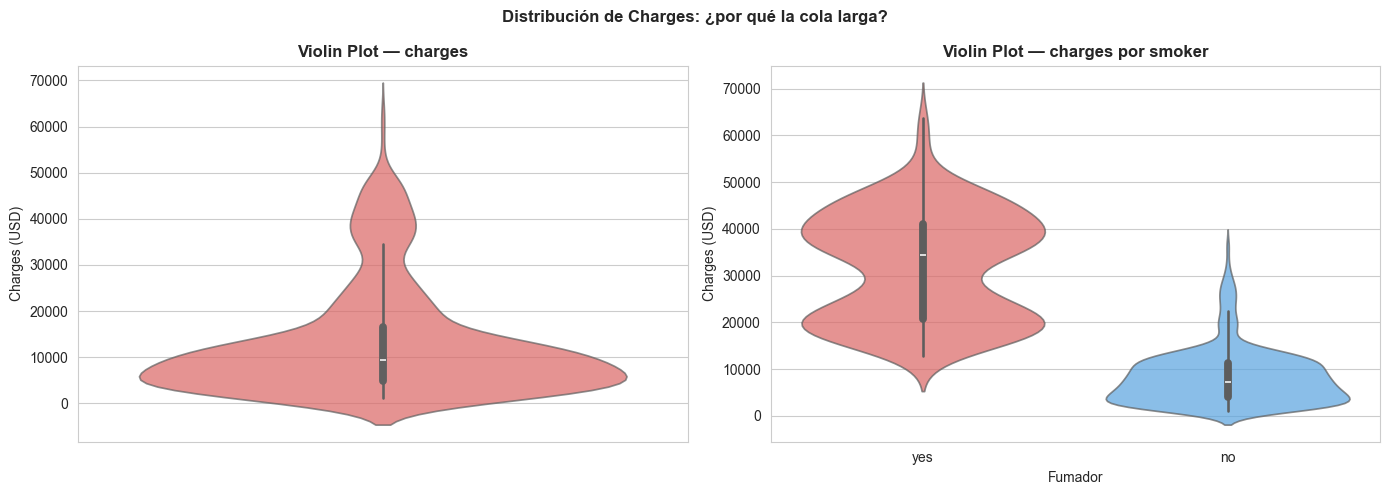

Hallazgo clave: los fumadores concentran los valores más altos de charges.
Lo que parecía un outlier puede ser un SUBGRUPO DIFERENCIADO.


In [8]:
# ── Violin plots: más información sobre la distribución ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin de charges
sns.violinplot(y=df['charges'], ax=axes[0], color='#EF5350', alpha=0.7)
axes[0].set_title('Violin Plot — charges', fontweight='bold')
axes[0].set_ylabel('Charges (USD)')

# Violin de charges por smoker — revela la bimodalidad
sns.violinplot(x=df['smoker'], y=df['charges'], ax=axes[1],
               palette={'yes':'#EF5350', 'no':'#42A5F5'}, alpha=0.7)
axes[1].set_title('Violin Plot — charges por smoker', fontweight='bold')
axes[1].set_xlabel('Fumador')
axes[1].set_ylabel('Charges (USD)')

plt.suptitle('Distribución de Charges: ¿por qué la cola larga?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Hallazgo clave: los fumadores concentran los valores más altos de charges.')
print('Lo que parecía un outlier puede ser un SUBGRUPO DIFERENCIADO.')

---
### 3.2 Método del Rango Intercuartil (RIC) — Tukey

El método de Tukey usa los cuartiles para definir umbrales de normalidad:

| Cálculo | Fórmula |
|---|---|
| Rango Intercuartil | RIC = Q3 − Q1 |
| Límite Inferior | LI = Q1 − 1.5 × RIC |
| Límite Superior | LS = Q3 + 1.5 × RIC |
| Límite Inferior Extremo | LIE = Q1 − 3 × RIC |
| Límite Superior Extremo | LSE = Q3 + 3 × RIC |

- **Outliers leves:** entre 1.5×RIC y 3×RIC del borde de la caja
- **Outliers extremos:** más de 3×RIC del borde de la caja


In [9]:
def analisis_ric(df, columna):
    Q1  = df[columna].quantile(0.25)
    Q3  = df[columna].quantile(0.75)
    RIC = Q3 - Q1
    LI  = Q1 - 1.5 * RIC
    LS  = Q3 + 1.5 * RIC
    LIE = Q1 - 3.0 * RIC
    LSE = Q3 + 3.0 * RIC

    leves   = df[(df[columna] < LI) & (df[columna] >= LIE) |
                 (df[columna] > LS) & (df[columna] <= LSE)]
    extremos = df[(df[columna] < LIE) | (df[columna] > LSE)]

    print(f'\n{'━'*55}')
    print(f'  Variable: {columna}')
    print(f'{'━'*55}')
    print(f'  Q1 = {Q1:>10.2f}   Q3 = {Q3:>10.2f}   RIC = {RIC:.2f}')
    print(f'  Lím. Inferior     = {LI:>10.2f}   Lím. Superior     = {LS:.2f}')
    print(f'  Lím. Inf. Extremo = {LIE:>10.2f}   Lím. Sup. Extremo = {LSE:.2f}')
    print(f'  Outliers leves:   {len(leves):>4} ({len(leves)/len(df)*100:.1f}%)')
    print(f'  Outliers extremos:{len(extremos):>4} ({len(extremos)/len(df)*100:.1f}%)')

    return Q1, Q3, RIC, LI, LS, LIE, LSE, leves, extremos

resultados_ric = {}
for var in ['age', 'bmi', 'charges']:
    resultados_ric[var] = analisis_ric(df, var)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Variable: age
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q1 =      27.00   Q3 =      51.00   RIC = 24.00
  Lím. Inferior     =      -9.00   Lím. Superior     = 87.00
  Lím. Inf. Extremo =     -45.00   Lím. Sup. Extremo = 123.00
  Outliers leves:      0 (0.0%)
  Outliers extremos:   0 (0.0%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Variable: bmi
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q1 =      26.30   Q3 =      34.69   RIC = 8.40
  Lím. Inferior     =      13.70   Lím. Superior     = 47.29
  Lím. Inf. Extremo =       1.10   Lím. Sup. Extremo = 59.89
  Outliers leves:      9 (0.7%)
  Outliers extremos:   0 (0.0%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Variable: charges
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q1 =    4740.29   Q3 =   16639.91   RIC = 11899.63
  Lím. Inferior     =  -13109.15   Lím. Superior     = 34489.35
  Lím. Inf. Extremo 

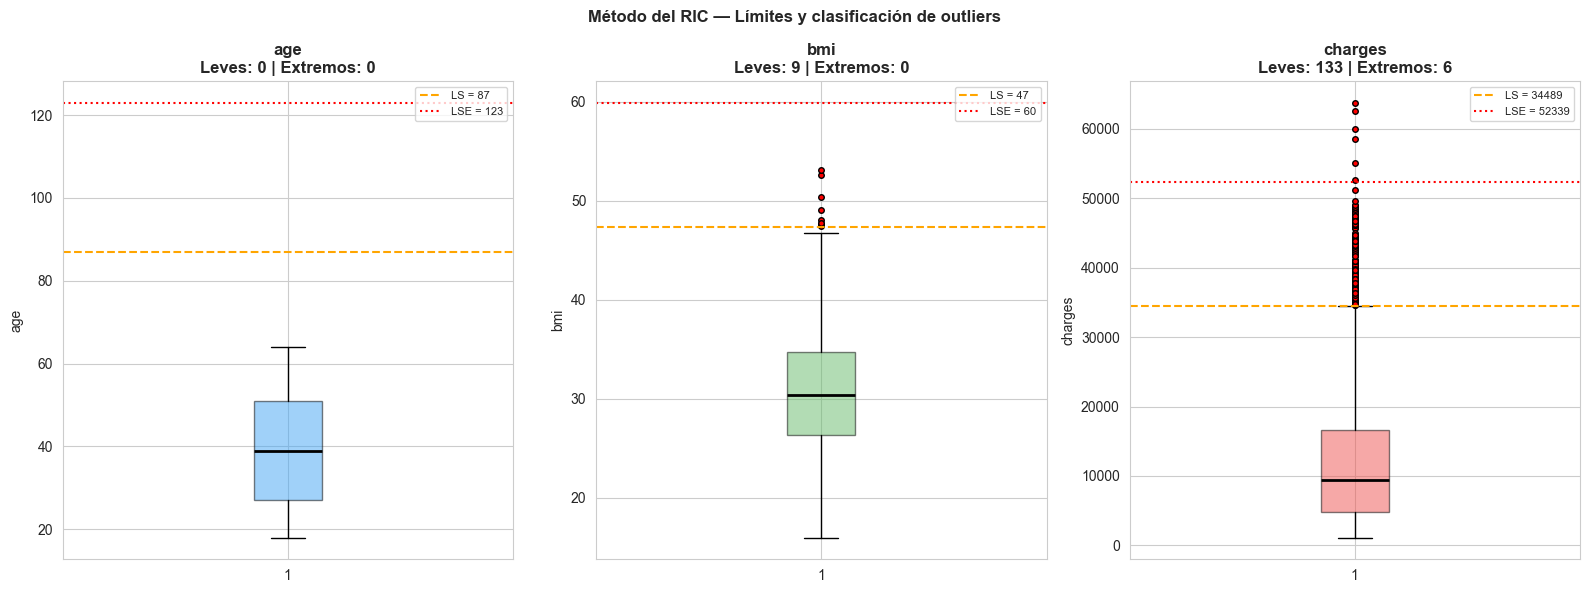

In [10]:
# ── Visualización del método RIC sobre boxplots anotados ──
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

variables = ['age', 'bmi', 'charges']
colores_v  = ['#42A5F5', '#66BB6A', '#EF5350']

for ax, var, color in zip(axes, variables, colores_v):
    Q1, Q3, RIC, LI, LS, LIE, LSE, leves, extremos = resultados_ric[var]

    ax.boxplot(df[var], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markerfacecolor='red', markersize=4))

    # Anotar límites
    ax.axhline(LS,  color='orange', linewidth=1.5, linestyle='--', label=f'LS = {LS:.0f}')
    ax.axhline(LSE, color='red',    linewidth=1.5, linestyle=':',  label=f'LSE = {LSE:.0f}')
    if LI > df[var].min():
        ax.axhline(LI,  color='orange', linewidth=1.5, linestyle='--', label=f'LI = {LI:.0f}')
    if LIE > df[var].min():
        ax.axhline(LIE, color='red',    linewidth=1.5, linestyle=':',  label=f'LIE = {LIE:.0f}')

    ax.set_title(f'{var}\nLeves: {len(leves)} | Extremos: {len(extremos)}', fontweight='bold')
    ax.set_ylabel(var)
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Método del RIC — Límites y clasificación de outliers', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 3.3 Método de la Puntuación Z (Z-score)

La puntuación Z mide cuántas **desviaciones estándar** se aleja un valor de la media:

$$Z_i = \frac{x_i - \bar{x}}{\sigma}$$

**Criterio estándar:** un valor es outlier si |Z| > 3  
*(bajo distribución normal, el 99.7% de los datos queda dentro de ±3σ)*

**Limitación importante:** Este método es sensible a los propios outliers (la media y la desviación estándar se ven afectadas por ellos).
Por eso se recomienda complementarlo con el método del RIC.


In [11]:
def analisis_zscore(df, columna, umbral=3):
    z_scores = np.abs(stats.zscore(df[columna]))
    outliers = df[z_scores > umbral]

    print(f'\n{'━'*55}')
    print(f'  Variable: {columna}  |  Umbral |Z| > {umbral}')
    print(f'{'━'*55}')
    print(f'  Media     = {df[columna].mean():.2f}')
    print(f'  Desv. est = {df[columna].std():.2f}')
    print(f'  Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')
    if len(outliers) > 0:
        print(f'  Rango de outliers: [{outliers[columna].min():.2f}, {outliers[columna].max():.2f}]')

    return z_scores, outliers

resultados_z = {}
for var in ['age', 'bmi', 'charges']:
    z, out = analisis_zscore(df, var)
    resultados_z[var] = (z, out)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Variable: age  |  Umbral |Z| > 3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Media     = 39.21
  Desv. est = 14.05
  Outliers detectados: 0 (0.0%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Variable: bmi  |  Umbral |Z| > 3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Media     = 30.66
  Desv. est = 6.10
  Outliers detectados: 4 (0.3%)
  Rango de outliers: [49.06, 53.13]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Variable: charges  |  Umbral |Z| > 3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Media     = 13270.42
  Desv. est = 12110.01
  Outliers detectados: 7 (0.5%)
  Rango de outliers: [51194.56, 63770.43]


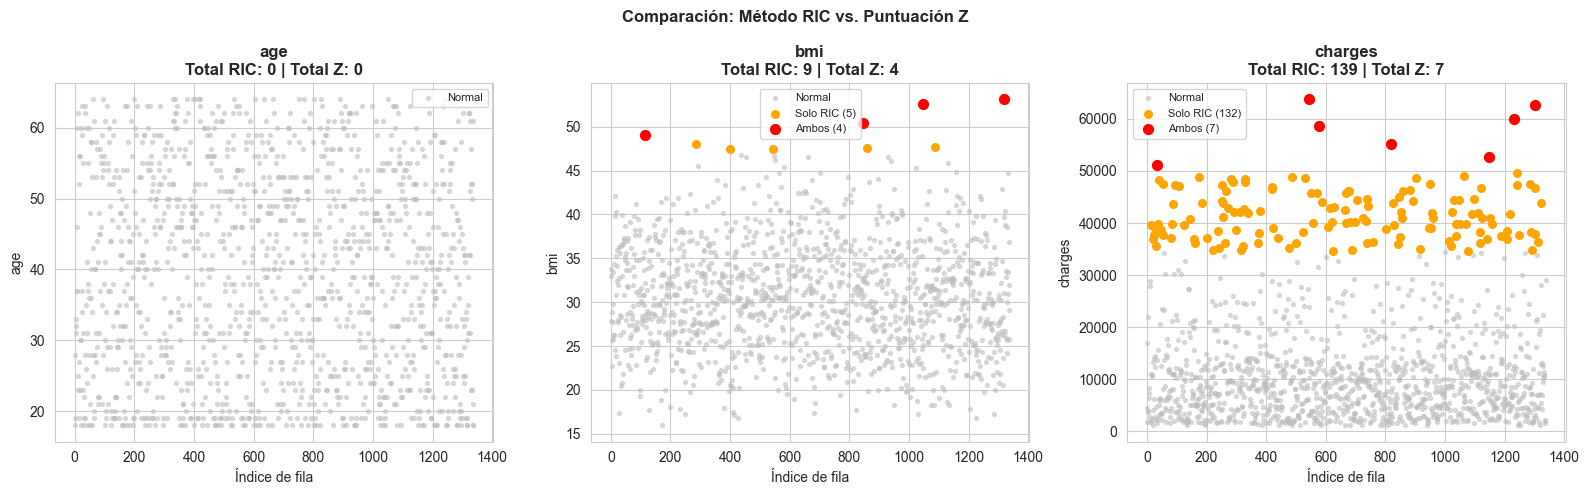

Observación: ambos métodos pueden detectar conjuntos distintos de outliers.
Se recomienda usar los dos y aplicar criterio de dominio para la decisión final.


In [12]:
# ── Comparación visual de ambos métodos ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, var, color in zip(axes, ['age', 'bmi', 'charges'], colores_v):
    Q1, Q3, RIC, LI, LS, LIE, LSE, leves_ric, ext_ric = resultados_ric[var]
    z_scores, out_z = resultados_z[var]

    idx_ric = set(leves_ric.index) | set(ext_ric.index)
    idx_z   = set(out_z.index)
    idx_ambos = idx_ric & idx_z
    idx_solo_ric = idx_ric - idx_z
    idx_solo_z   = idx_z - idx_ric

    ax.scatter(range(len(df)), df[var].values, c='#BDBDBD', s=8, alpha=0.5, label='Normal')
    if idx_solo_ric:
        ax.scatter(list(idx_solo_ric), df.loc[list(idx_solo_ric), var],
                   c='orange', s=30, zorder=3, label=f'Solo RIC ({len(idx_solo_ric)})')
    if idx_solo_z:
        ax.scatter(list(idx_solo_z), df.loc[list(idx_solo_z), var],
                   c='blue', s=30, zorder=3, label=f'Solo Z ({len(idx_solo_z)})')
    if idx_ambos:
        ax.scatter(list(idx_ambos), df.loc[list(idx_ambos), var],
                   c='red', s=50, zorder=4, label=f'Ambos ({len(idx_ambos)})')

    ax.set_title(f'{var}\nTotal RIC: {len(idx_ric)} | Total Z: {len(idx_z)}', fontweight='bold')
    ax.set_xlabel('Índice de fila')
    ax.set_ylabel(var)
    ax.legend(fontsize=8)

plt.suptitle('Comparación: Método RIC vs. Puntuación Z', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observación: ambos métodos pueden detectar conjuntos distintos de outliers.')
print('Se recomienda usar los dos y aplicar criterio de dominio para la decisión final.')

---
### 3.4 Investigación: ¿son errores o casos reales?

Detectar un outlier es solo el primer paso. La pregunta crítica es:  
**¿Este valor extremo es un error de medición o un caso real que revela algo importante?**

Para responderla necesitamos **conocimiento del dominio** y análisis de contexto.


In [13]:
# ── Investigar outliers de charges ──
Q1, Q3, RIC, LI, LS, LIE, LSE, leves, extremos = resultados_ric['charges']

# Obtener todos los outliers de charges
outliers_charges = pd.concat([leves, extremos]).drop_duplicates()

print(f'Total outliers en charges: {len(outliers_charges)}')
print(f'\n¿Cuántos de ellos son fumadores?')
print(outliers_charges['smoker'].value_counts())

print(f'\nPorcentaje de fumadores entre los outliers de charges:')
pct = outliers_charges['smoker'].value_counts(normalize=True)*100
print(pct.round(1))

Total outliers en charges: 139

¿Cuántos de ellos son fumadores?
smoker
yes    136
no       3
Name: count, dtype: int64

Porcentaje de fumadores entre los outliers de charges:
smoker
yes   97.80
no     2.20
Name: proportion, dtype: float64


In [14]:
# ── Estadísticas de charges por grupo fumador ──
print('Estadísticas de charges según estatus de fumador:')
print(df.groupby('smoker')['charges'].describe().round(2))

print('\nRazón entre medias (fumador / no fumador):')
ratio = df[df['smoker']=='yes']['charges'].mean() / df[df['smoker']=='no']['charges'].mean()
print(f'Los fumadores pagan en promedio {ratio:.1f}x más que los no fumadores.')

Estadísticas de charges según estatus de fumador:
         count     mean      std      min      25%      50%      75%      max
smoker                                                                       
no     1064.00  8434.27  5993.78  1121.87  3986.44  7345.41 11362.89 36910.61
yes     274.00 32050.23 11541.55 12829.46 20826.24 34456.35 41019.21 63770.43

Razón entre medias (fumador / no fumador):
Los fumadores pagan en promedio 3.8x más que los no fumadores.


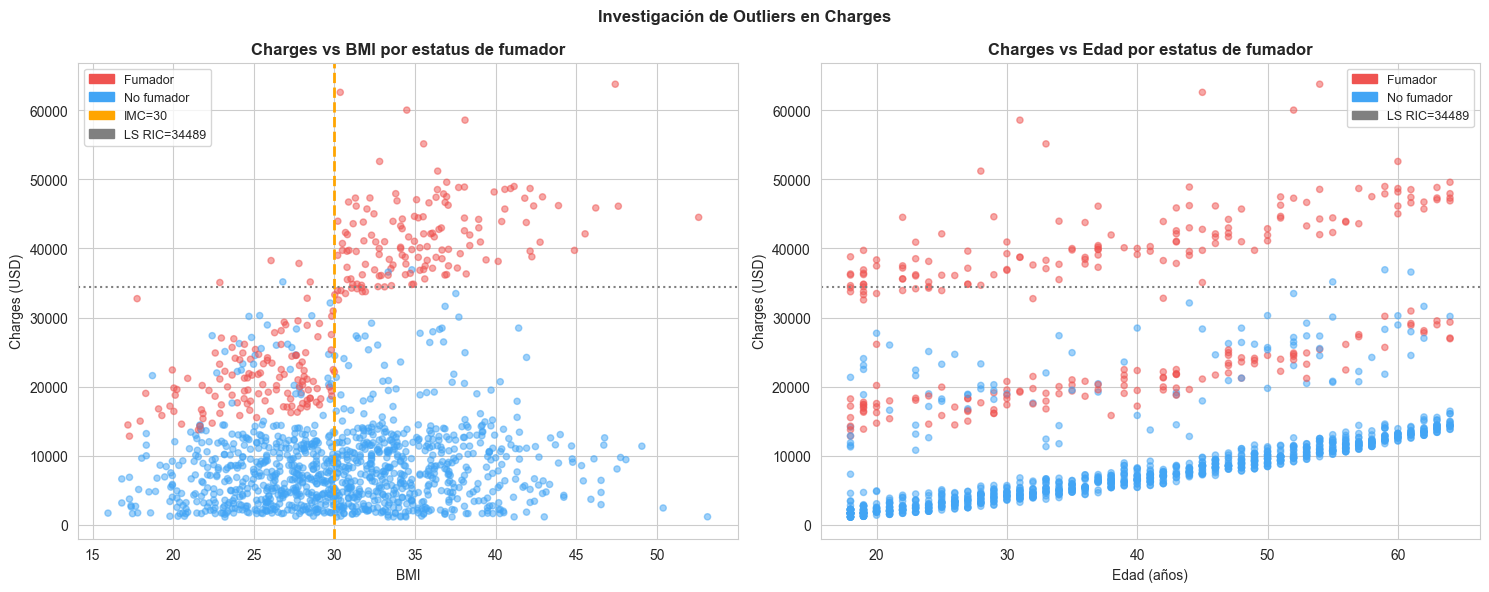

Conclusión: los outliers de charges forman DOS SUBGRUPOS claramente diferenciados:
  1. Fumadores con IMC > 30 → charges extremadamente altos
  2. Fumadores con IMC < 30 → charges altos pero no tanto
  → NO son errores. Son patrones reales del dominio médico.


In [15]:
# ── Scatter: charges vs bmi, coloreado por smoker ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# charges vs bmi
colores_smoker = df['smoker'].map({'yes': '#EF5350', 'no': '#42A5F5'})
axes[0].scatter(df['bmi'], df['charges'], c=colores_smoker, alpha=0.5, s=20)
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Charges (USD)')
axes[0].set_title('Charges vs BMI por estatus de fumador', fontweight='bold')
axes[0].axvline(30, color='orange', linewidth=2, linestyle='--', label='IMC=30 (umbral obesidad)')
axes[0].axhline(LS, color='gray',   linewidth=1.5, linestyle=':', label=f'Límite Superior RIC = {LS:.0f}')
patch_yes = mpatches.Patch(color='#EF5350', label='Fumador')
patch_no  = mpatches.Patch(color='#42A5F5', label='No fumador')
axes[0].legend(handles=[patch_yes, patch_no,
               mpatches.Patch(color='orange', label='IMC=30'),
               mpatches.Patch(color='gray', label=f'LS RIC={LS:.0f}')], fontsize=9)

# charges vs age
axes[1].scatter(df['age'], df['charges'], c=colores_smoker, alpha=0.5, s=20)
axes[1].set_xlabel('Edad (años)')
axes[1].set_ylabel('Charges (USD)')
axes[1].set_title('Charges vs Edad por estatus de fumador', fontweight='bold')
axes[1].axhline(LS, color='gray', linewidth=1.5, linestyle=':', label=f'LS RIC = {LS:.0f}')
axes[1].legend(handles=[patch_yes, patch_no,
               mpatches.Patch(color='gray', label=f'LS RIC={LS:.0f}')], fontsize=9)

plt.suptitle('Investigación de Outliers en Charges', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Conclusión: los outliers de charges forman DOS SUBGRUPOS claramente diferenciados:')
print('  1. Fumadores con IMC > 30 → charges extremadamente altos')
print('  2. Fumadores con IMC < 30 → charges altos pero no tanto')
print('  → NO son errores. Son patrones reales del dominio médico.')

---
### 3.5 Análisis de outliers en BMI con conocimiento del dominio

El Índice de Masa Corporal (IMC / BMI) tiene categorías clínicas bien definidas:

| Rango BMI | Categoría clínica |
|---|---|
| < 18.5 | Bajo peso |
| 18.5 – 24.9 | Normal |
| 25.0 – 29.9 | Sobrepeso |
| 30.0 – 34.9 | Obesidad grado I |
| 35.0 – 39.9 | Obesidad grado II |
| ≥ 40.0 | Obesidad grado III (mórbida) |

Los outliers detectados con IMC ≥ 40 o ≥ 50 corresponden a obesidad mórbida severa.  
¿Son errores? ¿O casos médicamente válidos aunque inusuales?


In [16]:
# ── Clasificar BMI por categoría clínica ──
def clasificar_bmi(bmi):
    if bmi < 18.5:  return 'Bajo peso'
    elif bmi < 25:  return 'Normal'
    elif bmi < 30:  return 'Sobrepeso'
    elif bmi < 35:  return 'Obesidad I'
    elif bmi < 40:  return 'Obesidad II'
    else:           return 'Obesidad III (mórbida)'

df['bmi_categoria'] = df['bmi'].apply(clasificar_bmi)

print('Distribución por categoría clínica de BMI:')
cat_counts = df['bmi_categoria'].value_counts()
cat_pct    = df['bmi_categoria'].value_counts(normalize=True)*100
print(pd.DataFrame({'Cantidad': cat_counts, 'Porcentaje (%)': cat_pct.round(1)}))

Distribución por categoría clínica de BMI:
                        Cantidad  Porcentaje (%)
bmi_categoria                                   
Obesidad I                   391           29.20
Sobrepeso                    386           28.80
Normal                       225           16.80
Obesidad II                  225           16.80
Obesidad III (mórbida)        91            6.80
Bajo peso                     20            1.50


In [18]:
# ── Outliers de BMI con contexto clínico ──
Q1b, Q3b, RICb, LIb, LSb, LIEb, LSEb, leves_bmi, ext_bmi = resultados_ric['bmi']

print(f'Límite Superior RIC para BMI: {LSb:.2f}')
print(f'Límite Superior Extremo para BMI: {LSEb:.2f}')

# Agregar bmi_categoria en el momento de mostrar (la columna no existía cuando se creó el subset)
cols_base = ['age', 'sex', 'bmi', 'smoker', 'charges']

print(f'\nOutliers leves de BMI (entre {LSb:.1f} y {LSEb:.1f}):')
print(
    leves_bmi[cols_base]
    .assign(bmi_categoria=leves_bmi['bmi'].apply(clasificar_bmi))
    .head(10)
)

print(f'\nOutliers extremos de BMI (> {LSEb:.1f}):')
if len(ext_bmi) > 0:
    print(
        ext_bmi[cols_base]
        .assign(bmi_categoria=ext_bmi['bmi'].apply(clasificar_bmi))
    )
else:
    print('  No se detectaron outliers extremos.')

print(f'\nBMI máximo en el dataset: {df["bmi"].max()}')
print(f'Corresponde a categoría: {clasificar_bmi(df["bmi"].max())}')

Límite Superior RIC para BMI: 47.29
Límite Superior Extremo para BMI: 59.89

Outliers leves de BMI (entre 47.3 y 59.9):
      age     sex   bmi smoker  charges           bmi_categoria
116    58    male 49.06     no 11381.33  Obesidad III (mórbida)
286    46  female 48.07     no  9432.93  Obesidad III (mórbida)
401    47    male 47.52     no  8083.92  Obesidad III (mórbida)
543    54  female 47.41    yes 63770.43  Obesidad III (mórbida)
847    23    male 50.38     no  2438.06  Obesidad III (mórbida)
860    37  female 47.60    yes 46113.51  Obesidad III (mórbida)
1047   22    male 52.58    yes 44501.40  Obesidad III (mórbida)
1088   52    male 47.74     no  9748.91  Obesidad III (mórbida)
1317   18    male 53.13     no  1163.46  Obesidad III (mórbida)

Outliers extremos de BMI (> 59.9):
  No se detectaron outliers extremos.

BMI máximo en el dataset: 53.13
Corresponde a categoría: Obesidad III (mórbida)


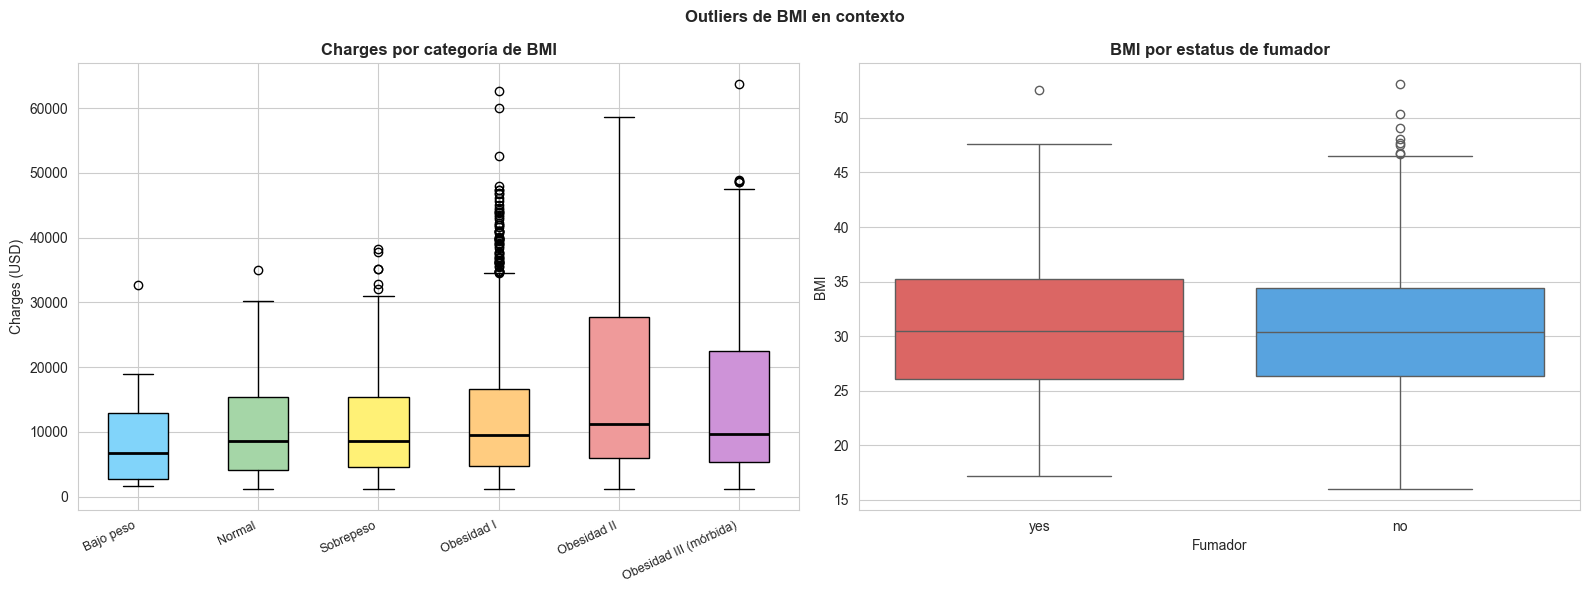

In [19]:
# ── Boxplot de charges por categoría BMI ──
orden_cat = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad I', 'Obesidad II', 'Obesidad III (mórbida)']
orden_existentes = [c for c in orden_cat if c in df['bmi_categoria'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot charges por categoría BMI
df_ord = df[df['bmi_categoria'].isin(orden_existentes)]
grupos = [df_ord[df_ord['bmi_categoria']==cat]['charges'].values for cat in orden_existentes]
bp = axes[0].boxplot(grupos, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
colores_bmi = ['#81D4FA','#A5D6A7','#FFF176','#FFCC80','#EF9A9A','#CE93D8']
for patch, color in zip(bp['boxes'], colores_bmi):
    patch.set_facecolor(color)
axes[0].set_xticklabels(orden_existentes, rotation=25, ha='right', fontsize=9)
axes[0].set_title('Charges por categoría de BMI', fontweight='bold')
axes[0].set_ylabel('Charges (USD)')

# BMI por smoker
sns.boxplot(x='smoker', y='bmi', data=df, palette={'yes':'#EF5350','no':'#42A5F5'}, ax=axes[1])
axes[1].set_title('BMI por estatus de fumador', fontweight='bold')
axes[1].set_xlabel('Fumador')
axes[1].set_ylabel('BMI')

plt.suptitle('Outliers de BMI en contexto', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 3.6 Impacto de los outliers en las estadísticas de resumen

Una de las razones por las que los outliers son problemáticos para la minería de datos es su **impacto desproporcionado** en las estadísticas y los modelos.
Cuantifiquemos ese impacto antes vs. después de eliminar los outliers de `charges`.


In [20]:
# ── Comparación de estadísticas con y sin outliers de charges ──
Q1c, Q3c, RICc, LIc, LSc, LIEc, LSEc, leves_c, ext_c = resultados_ric['charges']

# Dataset sin outliers de charges (solo para comparar, NO lo aplicamos definitivamente)
outliers_idx = set(leves_c.index) | set(ext_c.index)
df_sin_outliers = df.drop(index=list(outliers_idx))

estadisticas = pd.DataFrame({
    'Con outliers':    df['charges'].describe(),
    'Sin outliers':    df_sin_outliers['charges'].describe(),
}).round(2)

estadisticas['Diferencia (%)'] = (
    (estadisticas['Sin outliers'] - estadisticas['Con outliers'])
    / estadisticas['Con outliers'] * 100
).round(1)

print('Impacto de los outliers en las estadísticas de charges:')
print(estadisticas)

Impacto de los outliers en las estadísticas de charges:
       Con outliers  Sin outliers  Diferencia (%)
count       1338.00       1199.00          -10.40
mean       13270.42       9927.75          -25.20
std        12110.01       7241.16          -40.20
min         1121.87       1121.87            0.00
25%         4740.29       4408.70           -7.00
50%         9382.03       8410.05          -10.40
75%        16639.91      12953.59          -22.20
max        63770.43      34472.84          -45.90


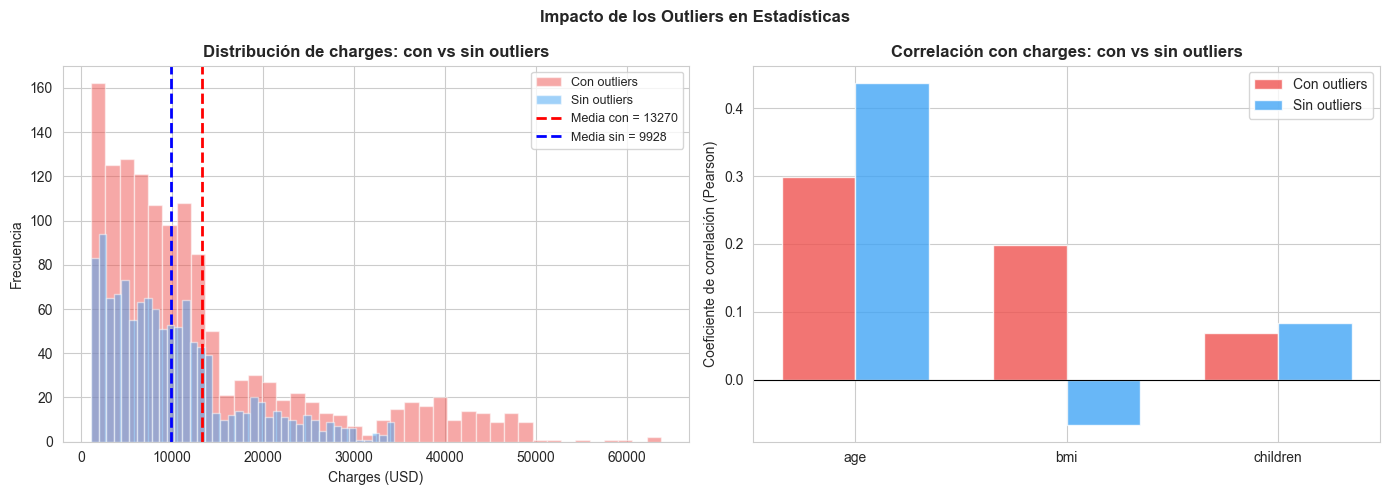

Observación: los outliers inflan la media y distorsionan las correlaciones.


In [21]:
# ── Visualización del impacto ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma comparativo
axes[0].hist(df['charges'], bins=40, alpha=0.5, color='#EF5350', label='Con outliers', edgecolor='white')
axes[0].hist(df_sin_outliers['charges'], bins=40, alpha=0.5, color='#42A5F5', label='Sin outliers', edgecolor='white')
axes[0].axvline(df['charges'].mean(),            color='red',  linewidth=2, linestyle='--', label=f'Media con = {df["charges"].mean():.0f}')
axes[0].axvline(df_sin_outliers['charges'].mean(), color='blue', linewidth=2, linestyle='--', label=f'Media sin = {df_sin_outliers["charges"].mean():.0f}')
axes[0].set_title('Distribución de charges: con vs sin outliers', fontweight='bold')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=9)

# Impacto en correlación con otras variables
vars_corr = ['age', 'bmi', 'children']
corr_con  = [df[v].corr(df['charges'])            for v in vars_corr]
corr_sin  = [df_sin_outliers[v].corr(df_sin_outliers['charges']) for v in vars_corr]

x = np.arange(len(vars_corr))
w = 0.35
axes[1].bar(x - w/2, corr_con, w, label='Con outliers',  color='#EF5350', alpha=0.8)
axes[1].bar(x + w/2, corr_sin, w, label='Sin outliers',  color='#42A5F5', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(vars_corr)
axes[1].set_title('Correlación con charges: con vs sin outliers', fontweight='bold')
axes[1].set_ylabel('Coeficiente de correlación (Pearson)')
axes[1].legend()
axes[1].axhline(0, color='black', linewidth=0.8)

plt.suptitle('Impacto de los Outliers en Estadísticas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observación: los outliers inflan la media y distorsionan las correlaciones.')

---
### 3.7 Decisión y justificación por variable

La detección de un outlier **no implica eliminarlo automáticamente**. La decisión depende de:
- El tipo de outlier (genuino vs espurio)
- El algoritmo de minería de datos que se usará
- El impacto que tiene en el resultado final


In [22]:
# ── Tabla resumen de decisiones ──
decision = pd.DataFrame({
    'Variable': ['charges', 'charges', 'bmi'],
    'Tipo de outlier': [
        'Leve (fumadores, cargos medios altos)',
        'Extremo (fumadores obesos, cargos muy altos)',
        'Leve/Extremo (IMC ≥ 47)'
    ],
    'Espurio o genuino': ['Genuino', 'Genuino', 'Genuino'],
    'Decisión': [
        'Conservar',
        'Conservar',
        'Conservar (verificar máximo)'
    ],
    'Justificación': [
        'Representan un subgrupo real: fumadores con costos más altos',
        'Representan el subgrupo más crítico: fumadores obesos. Son los casos más importantes para el modelo de predicción',
        'Obesidad mórbida es una condición médica real. El valor máximo (53.1) es extremo pero no imposible clínicamente'
    ]
})

print('DECISIONES DE TRATAMIENTO DE OUTLIERS:')
decision

DECISIONES DE TRATAMIENTO DE OUTLIERS:


,Variable,Tipo de outlier,Espurio o genuino,Decisión,Justificación
0,charges,"Leve (fumadores, cargos medios altos)",Genuino,Conservar,Representan un subgrupo real: fumadores con co...
1,charges,"Extremo (fumadores obesos, cargos muy altos)",Genuino,Conservar,Representan el subgrupo más crítico: fumadores...
2,bmi,Leve/Extremo (IMC ≥ 47),Genuino,Conservar (verificar máximo),Obesidad mórbida es una condición médica real....


In [23]:
# ── Efecto en el modelo: mostrar por qué son importantes ──
print('Charges promedio por segmento (fumador × categoría BMI):')
pivot = df.groupby(['smoker', 'bmi_categoria'])['charges'].mean().unstack()
print(pivot[orden_existentes].round(0).to_string())

print('\nConclusion: los "outliers" de charges representan el segmento de MAYOR RIESGO')
print('para la aseguradora. Eliminarlos haría que el modelo FALLE precisamente en los')
print('casos donde más importa la predicción.')

Charges promedio por segmento (fumador × categoría BMI):
bmi_categoria  Bajo peso   Normal  Sobrepeso  Obesidad I  Obesidad II  Obesidad III (mórbida)
smoker                                                                                       
no               5533.00  7686.00    8258.00     8532.00      9670.00                 8180.00
yes             18810.00 19942.00   22496.00    39641.00     42754.00                45468.00

Conclusion: los "outliers" de charges representan el segmento de MAYOR RIESGO
para la aseguradora. Eliminarlos haría que el modelo FALLE precisamente en los
casos donde más importa la predicción.


---
## 4. Dataset final y próximos pasos


In [24]:
# ── Eliminar columna auxiliar de clasificación BMI ──
# (se usó solo para análisis; en la transformación se puede incluir como feature)
df_final = df.copy()  # conservamos bmi_categoria como feature útil para el modelo

print('Estado del dataset final:')
print(f'  Filas:       {len(df_final)}')
print(f'  Columnas:    {df_final.shape[1]}')
print(f'  Outliers:    Conservados y documentados')
print(f'  Nulos:       {df_final.isnull().sum().sum()}')
print()
df_final.describe().round(2)

Estado del dataset final:
  Filas:       1338
  Columnas:    8
  Outliers:    Conservados y documentados
  Nulos:       0



,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [25]:
# Guardar el dataset analizado
df_final.to_csv('datasets/insurance_analizado.csv', index=False)
print('✓ Dataset guardado como: insurance_analizado.csv')

✓ Dataset guardado como: insurance_analizado.csv


---
## 5. Resumen y reflexiones finales

### Lecciones clave sobre outliers en minería de datos

**1. Detectar ≠ eliminar**  
Un outlier detectado por el método del RIC o Z-score es solo una *candidatura*. La decisión final siempre requiere análisis de dominio.

**2. Los outliers pueden ser los casos más importantes**  
En este dataset, los clientes con `charges` extremos (fumadores obesos) son precisamente el segmento que la aseguradora más necesita predecir. Eliminarlos sería el error más costoso.

**3. La bimodalidad es una señal, no un error**  
La distribución bimodal de `charges` reveló la existencia de dos subpoblaciones distintas. Esta es información valiosa que puede incorporarse al modelo como una variable nueva o usarse para segmentación.

**4. IQR vs Z-score: métodos complementarios**  
El IQR es más robusto porque no depende de la media ni la desviación estándar (que se ven afectadas por los propios outliers). El Z-score es útil cuando la distribución es aproximadamente normal.

**5. El contexto del algoritmo importa**  
- Árboles de decisión y Random Forest → **robustos** a outliers
- Regresión lineal, KNN, SVM → **sensibles**: se debe normalizar para reducir el impacto

### Próximos pasos

| Etapa | Tarea |
|---|---|
| **Transformación** | Codificar variables categóricas (sex, smoker, region) |
| **Transformación** | Normalizar variables numéricas (MinMaxScaler o RobustScaler para datos con outliers) |
| **Transformación** | Considerar `bmi_categoria` como nueva variable predictora |
| **Minería de datos** | Aplicar regresión (predecir `charges`) |
| **Evaluación** | Medir RMSE, MAE, R² con y sin el segmento de outliers |
